In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

np.set_printoptions(precision=10, suppress=True)

# ==================================================
# Load data
# ==================================================

N = 50
L_list = [30, 40, 50, 60, 70, 80]

all_data = []

for L in L_list:

    numerical_data = np.loadtxt(
        f"gap_vs_Ef_kx_N{N}_L{L}_y.dat",
        skiprows=1
    )

    perturbative_data = np.loadtxt(
        f"Pymablock_gap_vs_Ef_kx_Y_N{N}_L{L}_short_k_range.dat",
        skiprows=1
    )

    # ==================================================
    # Relative error
    # ==================================================

    denom = np.abs(numerical_data[:, 5])

    relative_error = np.full_like(denom, np.nan, dtype=float)

    nonzero_gap = denom != 0

    relative_error[nonzero_gap] = (
        np.abs(
            numerical_data[nonzero_gap, 5]
            - perturbative_data[nonzero_gap, 3]
        )
        / denom[nonzero_gap]
    ) * 100

    # ==================================================
    # Build data array
    # ==================================================

    data = np.column_stack((
        np.full(len(numerical_data), L),   # L  
        numerical_data[:, 1] * 1e4,        # Efield
        numerical_data[:, 2],              # kx
        numerical_data[:, 3],              # E0
        numerical_data[:, 4],              # E1
        numerical_data[:, 5],              # numerical gap
        perturbative_data[:, 3],           # perturbative gap
        relative_error                     # relative error
    ))

    # ==================================================
    # Remove unwanted rows
    # ==================================================

    data = data[
        (data[:, 1] != 0) &
        (data[:, 2] != 0)
    ]

    data = data[np.isfinite(data[:, 7])]

    all_data.append(data)

# ==================================================
# Combine all L values together
# ==================================================

combined_data = np.vstack(all_data)

# ==================================================
# Save combined file
# ==================================================

np.savetxt(
    "gap_comparison_data.dat",
    combined_data,
    header=(
        "L Efield kx E0 E1 numerical_gap perturbative_gap relative_error_percent"
    ),
    fmt=(
        "%5d "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.4f"
    )
)

print("Combined data file saved successfully.")

Combined data file saved successfully.


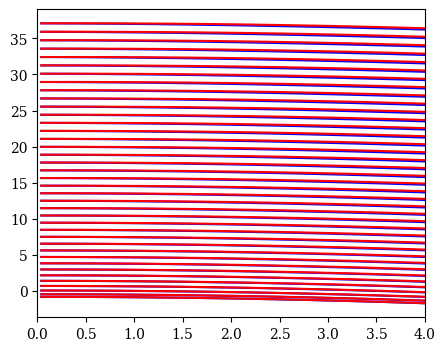

In [15]:
kx = data[:, 2]
band = data[:, 3]*1000
band2 = data[:, 4]*1000
for n in range(0, 40):
    # print(np.unique(data[:,0][n*99:(n+1)*99]))
    plt.plot(kx[n*99:(n+1)*99]*1000, band[n*99:(n+1)*99], color = 'blue')
    plt.plot(kx[n*99:(n+1)*99]*1000, band2[n*99:(n+1)*99], color = 'red')
    plt.xlim(0, 4)
    # plt.ylim(-10.87, -0)
plt.show()


0.00101


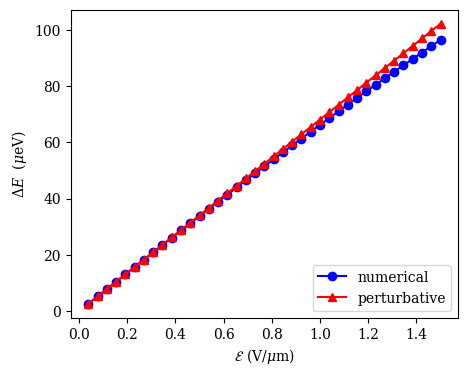

In [16]:
full_data = np.loadtxt("gap_comparison_data.dat")[:99*39]
start = 24
Efield = full_data[:,1][start::99]
kval = full_data[:,2][start::99]
numsplit = full_data[:,5][start::99]
persplit = full_data[:,6][start::99]
error = full_data[:,7][start::99]
print(kval[0])
plt.plot(Efield, numsplit, '-o', color = "blue", label = "numerical")
plt.plot(Efield, persplit, '-^', color = "red", label = "perturbative")
plt.xlabel(r"$\mathcal{E}$ (V/$\mu$m)")
plt.ylabel(r"$\Delta E$  ($\mu$eV)")
plt.legend(loc = "lower right")
plt.show()
# print(Efield)
# print(numsplit)
# print(persplit)

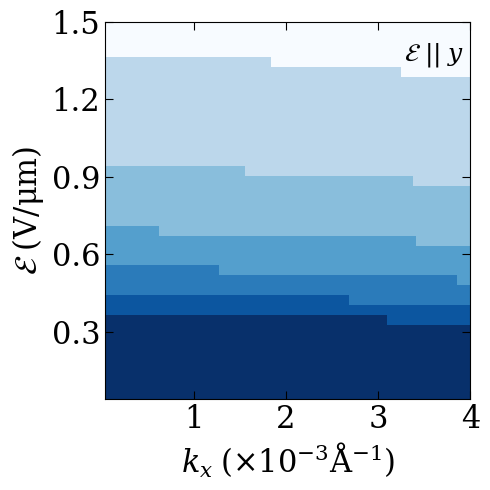

In [17]:
# ==================================================
# Plot settings
# ==================================================

plt.rcParams.update({
    "figure.figsize": [5, 5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif"
})

# ==================================================
# Extract columns from combined data
# ==================================================

size_all = combined_data[:, 0]

Efield = combined_data[:, 1]

# Convert kx to 10^{-3} Angstrom^{-1}
kx = combined_data[:, 2] * 1e3

relerr = combined_data[:, 7]

sizes_for_ey = np.unique(size_all)
# print("Unique L values:", sizes_for_ey)

kx_vals = np.unique(kx)
E_vals  = np.unique(Efield)
# print(kx_vals.max())

Nx = len(kx_vals)
NE = len(E_vals)

# ------------------ Build cumulative validity field ------------------
V = np.zeros((NE, Nx))  # 0 = invalid everywhere

threshold = 5  # 0.1 %

for level, size0 in enumerate(sizes_for_ey, start=2):

    mask = size_all == size0
    Z = relerr[mask].reshape(NE, Nx)

    valid = Z < threshold
    V[valid] = level   # overwrite → nested structure

# ------------------ Colormap (dark → light blue) ------------------

levels = np.arange(0, len(sizes_for_ey) + 3)

# Use Blues colormap exactly as before
cmap = plt.cm.Blues

# Normalize so each integer level maps cleanly
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
norm = BoundaryNorm(levels, cmap.N)

plt.figure()

# ----------- DISCRETE PIXEL MAP (NO INTERPOLATION) -----------
plt.pcolormesh(
    kx_vals,
    E_vals,
    V,
    cmap=cmap,
    norm=norm,
    shading="nearest"   # <-- critical: no smoothing
)

# # ---- Contour boundaries ----
# CS = plt.contour(
#     kx_vals,
#     E_vals,
#     V,
#     levels=np.arange(len(sizes_for_ey)),
#     colors='black',
#     linewidths=0.
# )


# n_levels = len(CS.levels)
# # create red→blue gradient
# label_colors = cm.gist_heat(np.linspace(0, 1, n_levels))

# # ---- Contour-aligned labels ----
# fmt = {i: f"{int(sizes_for_ey[i])} nm" for i in range(len(sizes_for_ey))}


# plt.clabel(
#     CS,
#     CS.levels,
#     inline=True,
#     fmt=fmt,
#     fontsize=14,
#     colors = label_colors
# )


# Label position (move outside loop)
plt.text(
    max(kx_vals) * 0.82,
    max(E_vals) * 0.9,
    r"$\mathcal{E}\;||\;y$",
    fontsize=18
)

# ------------------ Labels & layout ------------------
plt.xlabel(r"$k_x\;( \times 10^{-3} \mathrm{\AA}^{-1})$", fontsize=22)
plt.ylabel(r"$\mathcal{E} \;(\mathrm{V/\mu m})$", fontsize=22)

plt.tick_params(direction='in', top=True, right=True, length=6, labelsize=22)

plt.xlim(kx_vals.min(), kx_vals.max())
plt.ylim(E_vals.min(), E_vals.max())

plt.yticks([0.3, 0.6, 0.9, 1.2, 1.5])
plt.xticks([1, 2, 3, 4])
# plt.axvline(x = 1, color = 'yellow', ls = '--')
# plt.axhline(y = 0.1, color = 'yellow', ls = '--')
# plt.plot(1, 0.1, 'o', mfc='none', mec='red', mew=1, markersize=10)

plt.tight_layout()
plt.savefig("phase_diagram_Ey.png", dpi=300)
plt.savefig("phase_diagram_Ey.pdf")
plt.show()


Combined data file saved successfully.


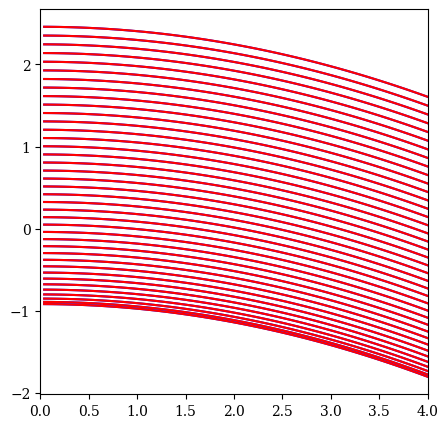

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

np.set_printoptions(precision=10, suppress=True)

# ==================================================
# Load data
# ==================================================

N = 50
L_list = [30,40,50, 60, 70, 80]

all_data = []

for L in L_list:

    numerical_data = np.loadtxt(
        f"gap_vs_Ef_kx_N{N}_L{L}_z.dat",
        skiprows=1
    )

    perturbative_data = np.loadtxt(
        f"Pymablock_gap_vs_Ef_kx_Z_N{N}_L{L}.dat",
        skiprows=1
    )

    # ==================================================
    # Relative error
    # ==================================================

    denom = np.abs(numerical_data[:, 5])

    relative_error = np.full_like(denom, np.nan, dtype=float)

    nonzero_gap = denom != 0

    relative_error[nonzero_gap] = (
        np.abs(
            numerical_data[nonzero_gap, 5]
            - perturbative_data[nonzero_gap, 3]
        )
        / denom[nonzero_gap]
    ) * 100

    # ==================================================
    # Build data array
    # ==================================================

    data = np.column_stack((
        np.full(len(numerical_data), L),   # L  
        numerical_data[:, 1] * 1e4,        # Efield
        numerical_data[:, 2],              # kx
        numerical_data[:, 3],              # E0
        numerical_data[:, 4],              # E1
        numerical_data[:, 5],              # numerical gap
        perturbative_data[:, 3],           # perturbative gap
        relative_error                     # relative error
    ))

    # ==================================================
    # Remove unwanted rows
    # ==================================================

    data = data[
        (data[:, 1] != 0) &
        (data[:, 2] != 0)
    ]

    data = data[np.isfinite(data[:, 7])]

    all_data.append(data)

# ==================================================
# Combine all L values together
# ==================================================

combined_data = np.vstack(all_data)

# ==================================================
# Save combined file
# ==================================================

np.savetxt(
    "gap_comparison_data.dat",
    combined_data,
    header=(
        "L Efield kx E0 E1 numerical_gap perturbative_gap relative_error_percent"
    ),
    fmt=(
        "%5d "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.4f"
    )
)

print("Combined data file saved successfully.")


kx = data[:, 2]
band = data[:, 3]*1000
band2 = data[:, 4]*1000
for n in range(0, 40):
    # print(np.unique(data[:,0][n*99:(n+1)*99]))
    plt.plot(kx[n*99:(n+1)*99]*1000, band[n*99:(n+1)*99], color = 'blue')
    plt.plot(kx[n*99:(n+1)*99]*1000, band2[n*99:(n+1)*99], color = 'red')
    plt.xlim(0, 4)
    # plt.ylim(-10.87, -0)
plt.show()


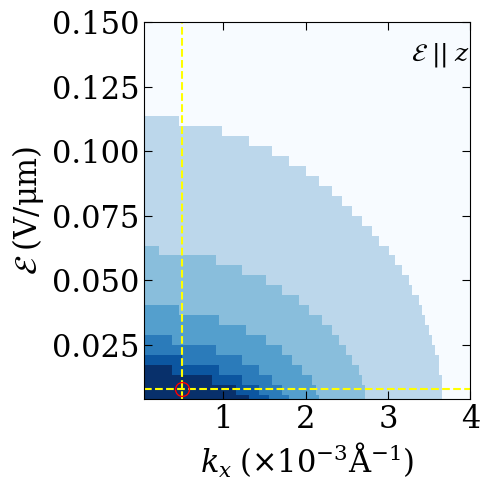

In [19]:
# ==================================================
# Plot settings
# ==================================================

plt.rcParams.update({
    "figure.figsize": [5, 5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif"
})

# ==================================================
# Extract columns from combined data
# ==================================================

size_all = combined_data[:, 0]

Efield = combined_data[:, 1]

# Convert kx to 10^{-3} Angstrom^{-1}
kx = combined_data[:, 2] * 1e3

relerr = combined_data[:, 7]

sizes_for_ey = np.unique(size_all)
# print("Unique L values:", sizes_for_ey)

kx_vals = np.unique(kx)
E_vals  = np.unique(Efield)

Nx = len(kx_vals)
NE = len(E_vals)

# ------------------ Build cumulative validity field ------------------
V = np.zeros((NE, Nx))  # 0 = invalid everywhere

threshold = 5  # 0.1 %

for level, size0 in enumerate(sizes_for_ey, start=2):

    mask = size_all == size0
    Z = relerr[mask].reshape(NE, Nx)

    valid = Z < threshold
    V[valid] = level   # overwrite → nested structure

# ------------------ Colormap (dark → light blue) ------------------

levels = np.arange(0, len(sizes_for_ey) + 3)

# Use Blues colormap exactly as before
cmap = plt.cm.Blues

# Normalize so each integer level maps cleanly
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
norm = BoundaryNorm(levels, cmap.N)

plt.figure()

# ----------- DISCRETE PIXEL MAP (NO INTERPOLATION) -----------
plt.pcolormesh(
    kx_vals,
    E_vals,
    V,
    cmap=cmap,
    norm=norm,
    shading="nearest"   # <-- critical: no smoothing
)

# # ---- Contour boundaries ----
# CS = plt.contour(
#     kx_vals,
#     E_vals,
#     V,
#     levels=np.arange(len(sizes_for_ey)),
#     colors='black',
#     linewidths=0.
# )


# n_levels = len(CS.levels)
# # create red→blue gradient
# label_colors = cm.gist_heat(np.linspace(0, 1, n_levels))

# # ---- Contour-aligned labels ----
# fmt = {i: f"{int(sizes_for_ey[i])} nm" for i in range(len(sizes_for_ey))}


# plt.clabel(
#     CS,
#     CS.levels,
#     inline=True,
#     fmt=fmt,
#     fontsize=14,
#     colors = label_colors
# )


# Label position (move outside loop)
plt.text(
    max(kx_vals) * 0.82,
    max(E_vals) * 0.9,
    r"$\mathcal{E}\;||\;z$",
    fontsize=18
)

# ------------------ Labels & layout ------------------
plt.xlabel(r"$k_x\;( \times 10^{-3} \mathrm{\AA}^{-1})$", fontsize=22)
plt.ylabel(r"$\mathcal{E} \;(\mathrm{V/\mu m})$", fontsize=22)

plt.tick_params(direction='in', top=True, right=True, length=6, labelsize=22)

plt.xlim(kx_vals.min(), kx_vals.max())
plt.ylim(E_vals.min(), E_vals.max())

# plt.yticks([0.3, 0.6, 0.9, 1.2])
plt.xticks([1,2,3,4])
plt.axvline(x = 0.5, color = 'yellow', ls = '--')
plt.axhline(y = 0.008, color = 'yellow', ls = '--')
plt.plot(0.5, 0.008, 'o', mfc='none', mec='red', mew=1, markersize=10)

plt.tight_layout()
plt.savefig("phase_diagram_Ez.png", dpi=300)
plt.savefig("phase_diagram_Ez.pdf")
plt.show()
